# Mnist from scratch

https://github.com/LorenzoVaralo/MNIST-from-Scratch

In [336]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt
import pickle #optional
from pathlib import Path
import functional as pyfn
import os

In [337]:
BIN_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/dataset-128/train"
BIN_TEST_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/dataset-128/test"
T_SM_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/kaggle-finger-count/small-test"
TR_MID_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/kaggle-finger-count/mid-train"
TR_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/kaggle-finger-count/train"
TR_8H_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/kaggle-finger-count/train-8H"
DATA_DIR = BIN_DIR
DATA_DIM = 16384

In [338]:
def load_bin(fn: Path):
    finger = int(fn.name[1])
    with open(fn, 'rb') as f:
        return np.frombuffer(f.read(), dtype=np.uint8).astype(np.float32) / 255.0, finger
        

def load_png(fn: Path):
    from PIL import Image

    img = Image.open(fn)
    img_array = np.array(img).astype(np.float32) / 255.0
    finger = int(fn.stem[-2])

    #print(f"img array shape: {img_array.shape}")
    img_array = img_array.flatten()
    #print(f"img array shape after flatten: {img_array.shape}")
    return img_array, finger

def create_ds(dp: str):
    bin_files = os.listdir(dp)
    print(bin_files)

    if Path(bin_files[0]).suffix == ".bin":
        load_fun = load_bin
    else:
        load_fun = load_png
        
    tmp_data = pyfn.seq(bin_files).map(lambda fn: Path(dp) / fn).map(load_fun).filter(lambda t: t[1] != 0).to_list()

    bin_data = np.array([item[0] for item in tmp_data])
    label = np.array([item[1] for item in tmp_data])
    print(f"train label: {label}")
    print(f"finger data {label[4]} has data shape: {bin_data[4].shape}")

    return bin_data, label

['52b.bin', '42b.bin', '54b.bin', '11b.bin', '35b.bin', '45b.bin', '25b.bin', '13b.bin', '53b.bin', '14b.bin', '12b.bin', '21b.bin', '41b.bin', '43b.bin', '44b.bin', '31b.bin', '15b.bin', '55b.bin', '34b.bin', '32b.bin', '24b.bin', '22b.bin', '51b.bin', '23b.bin', '33b.bin']
train label: [2 2 4 1 5 5 5 3 3 4 2 1 1 3 4 1 5 5 4 2 4 2 1 3 3]
finger data 5 has data shape: (16384,)
X shape: (25, 16384)
total 25 data loaded
train data
occurance of  1 = 5
occurance of  2 = 5
occurance of  3 = 5
occurance of  4 = 5
occurance of  5 = 5
y_value:
[[5. 5. 5. 5. 5.]]


<BarContainer object of 5 artists>

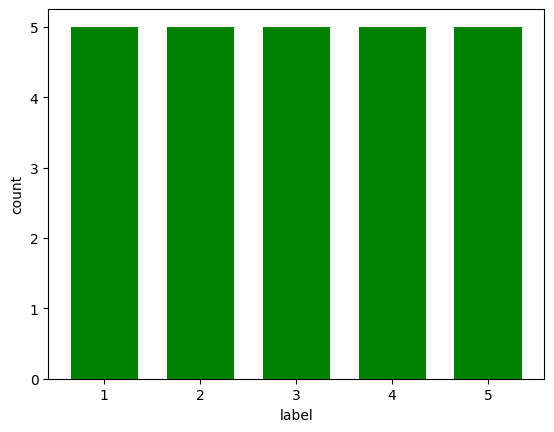

In [339]:
#Download do dataset e tratamento de dados:
X, Y = create_ds(DATA_DIR)

print(f"X shape: {X.shape}")

sample_cnt = len(X)
print(f"total {sample_cnt} data loaded")

print("train data")
y_value = np.zeros((1, 5))
for i in range (1, 6):
    print("occurance of ", i , "=", np.count_nonzero(Y==i))
    y_value[0, i-1] = np.count_nonzero(Y==i)

    
print(f"y_value:\n{y_value}")

y_value=y_value.ravel()
x_value=[1,2,3,4,5]
plt.xlabel('label')
plt.ylabel('count')
plt.bar(x_value,y_value,0.7,color='g')

sample 4 data with label 1:
[0.         0.         0.         0.         0.         0.
 0.         0.02745098 0.11372549 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


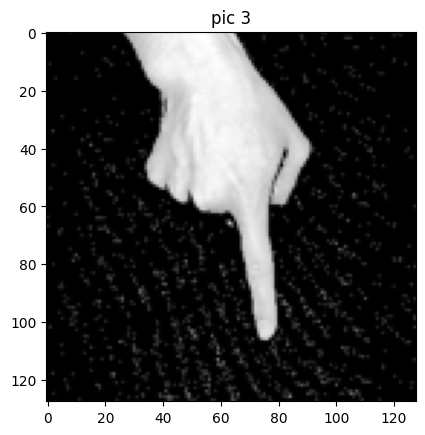

In [340]:

index = 3
print(f"sample 4 data with label {Y[index]}:\n{X[index][:20]}")
plt.title(f"pic {index}")
plt.imshow(X[index].reshape(128, 128), cmap='gray')


In [341]:
XT, YT = create_ds(BIN_TEST_DIR)

def process_ds(X1, Y1):
    m = X1.shape[0]
    n = X1.shape[1] + 1
    X2 = np.concatenate((np.ones([m,1]),X1), axis=1) # Adicionando a coluna de 1's para suportar o bias
    Y2 = Y1.astype(np.int64)
    print(f"first 3 Y: {Y2[:3]}")
    cat = np.zeros([m,5])
    print(f"cat shape: {cat.shape}")
    for ind, num in enumerate(Y2):
        cat[ind][num-1] = 1
    Y3 = cat # Y agora é categórico-> ex: 3 = [0,0,0,1,0,0,0,0,0,0]

    return X2, Y3

X, Y = process_ds(X, Y)
XT, YT = process_ds(XT, YT)

#Embaralhar e separar x e y em train e test:
#x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=42) 
x_train, x_test, y_train, y_test = X, XT, Y, YT

['64b.bin', '62b.bin', '63b.bin', '65b.bin', '61b.bin']
train label: [4 2 3 5 1]
finger data 1 has data shape: (16384,)
first 3 Y: [2 2 4]
cat shape: (25, 5)
first 3 Y: [4 2 3]
cat shape: (5, 5)


In [342]:
print('TAMANHOS:')
print(f'- X original: {X.shape[0]} x {X.shape[1]}')
print(f'- Y original: {Y.shape[0]} x {Y.shape[1]}')
print(f'- X Train: {x_train.shape[0]} x {x_train.shape[1]}')
print(f'- Y train: {y_train.shape[0]} x {y_train.shape[1]}')
print(f'- X Test: {x_test.shape[0]} x {x_test.shape[1]}')
print(f'- Y Test: {y_test.shape[0]} x {y_test.shape[1]}')

TAMANHOS:
- X original: 25 x 16385
- Y original: 25 x 5
- X Train: 25 x 16385
- Y train: 25 x 5
- X Test: 5 x 16385
- Y Test: 5 x 5


0


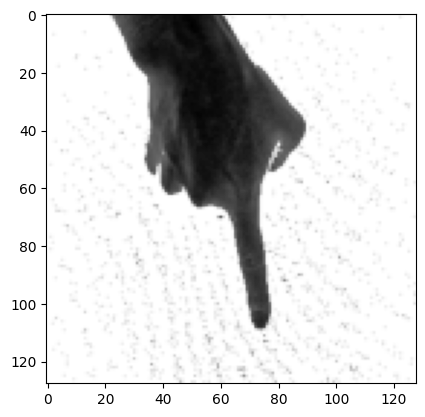

In [343]:
NumeroAleatorio = np.random.randint(0,len(x_train))
plt.imshow(np.reshape(x_train[NumeroAleatorio][1:], [128,128]), cmap='Greys')
print(np.argmax(y_train[NumeroAleatorio]))

In [344]:
class MNISTalgorithm:
    def __init__(self, estrutura, epochs=10, alpha=0.1, batch_size=0, Regularizer=0.0):
        self.tamanhos = [x for x in estrutura if isinstance(x, int)]
        self.ativações = [x.lower() for x in estrutura if isinstance(x, str)]
        self.inputs = [epochs,alpha,batch_size,Regularizer]
        self.epochs = epochs
        self.alpha = alpha
        self.Reg = Regularizer
        self.batch_size = batch_size
        self.Thetas = self.Inicialização()
        self.CheckInputs()
    

    def CheckInputs(self): #Aviso de possiveis erros
        assert isinstance(self.epochs,int), 'ERRO: parametro "epochs" deve ser integer.'
        assert isinstance(self.alpha,float), 'ERRO: parametro "alpha" deve ser float.'
        assert isinstance(self.batch_size,int), 'ERRO: parametro "batch_size" deve ser integer.'
        assert isinstance(self.Reg,float), 'ERRO: parametro "Regularizer" deve ser float.'
        #assert (self.tamanhos[0] == 784) and (self.tamanhos[-1] == 10),'ERRO: A primeira camada deve ter 784 neurônios e a ultima 10 neurônios.'
        assert len(self.ativações) == (len(self.tamanhos)-1), 'ERRO: Quantidade de camadas e ativações incompatível.'
        #assert self.ativações[-1] == 'softmax', 'ERRO: A ultima ativação deve ser Softmax.'


    def Inicialização(self):# Inicializando Weights e Bias aleatoriamente
        Thetas = {}
        for layer in range(len(self.tamanhos)-1):
            Thetas[f'T{layer+1}'] = np.random.randn(self.tamanhos[layer]+1, self.tamanhos[layer+1])/10
        return Thetas


    def sigmoid(self, z):
        return 1/(1 + np.exp(-z))

    def dxsigmoid(self, z):
        return np.multiply(self.sigmoid(z),(1-self.sigmoid(z)))

    def softmax(self,x):
        x = np.array(x)
        e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return (e_x / e_x.sum(axis=1)[:,None])

    def Relu(self, x):
        return np.maximum(0,x)
    
    def dxRelu(self, x):
        return np.where(x >= 0, 1, 0)
    

    def Forward(self,X):
        '''Adicionando todo processo da Forward Propagation em um dicionario
        {"a1": [...], "z2": [...], "a2": [...], "z3": [...], ..... ,"h":[...]}'''
        X = np.matrix(X)
        m = X.shape[0]
        att = self.ativações
        Thetas = self.Thetas
        Forward_steps = {}
        Forward_steps['a1'] = X
        Ultimo_layer = int(len(self.tamanhos))
        for layer in range(1,Ultimo_layer):
            Forward_steps[f'z{layer+1}'] = np.dot(Forward_steps[f'a{layer}'], Thetas[f'T{layer}'])
            if att[layer-1] == 'sigmoid':
                Forward_steps[f'a{layer+1}'] = np.concatenate((np.ones([m,1]), self.sigmoid(Forward_steps[f'z{layer+1}'])), axis=1)
            elif att[layer-1] == 'softmax':
                Forward_steps[f'a{layer+1}'] = np.concatenate((np.ones([m,1]), self.softmax(Forward_steps[f'z{layer+1}'])), axis=1)
            elif att[layer-1] == 'relu':
                Forward_steps[f'a{layer+1}'] = np.concatenate((np.ones([m,1]), self.Relu(Forward_steps[f'z{layer+1}'])), axis=1)
            else:
                print('ERRO NAS ATIVAÇÕES')

        
        h = Forward_steps.pop(f'a{Ultimo_layer}')
        Forward_steps['h'] = h[:,1:]
        
        return Forward_steps
        

    def CostFunction(self):
        '''É calculado a logistic Cost Function para todas as classes(10) e todas as rows(59500)'''
        Y = self.Y
        X = self.X
        Thetas = self.Thetas
        m = self.m
        Reg = self.Reg
        soma_weights = 0
        for i in range(len(Thetas)):
            weights = Thetas[f'T{i+1}']
            weights[0] = 0
            soma_weights += np.sum(weights**2)
        Forward_dict = self.Forward(X)
        h = Forward_dict['h']
        soma = np.sum((np.multiply(-Y , np.log(h)) - np.multiply((1-Y),(np.log(1-h)))))
        J = soma/m + (Reg/(2*m)) * soma_weights
        return J


    def Gradients(self,X,Y):
        '''Calcular a derivada de todos Thetas w.r.t Cost function, 
        é organizado utilizando um dicionario contendo os deltas.
        {...., "delta2": [...], "delta1": [...]}'''
        X = np.matrix(X)
        Y = np.matrix(Y)
        m = X.shape[0]
        Thetas = self.Thetas
        n_layers = len(self.tamanhos)
        att = self.ativações
        Thetas_grad = []

        Forward_list = self.Forward(X)
        deltas = {}
        deltas[f'delta{n_layers}'] = Forward_list['h'] - Y # delta4
        for i in range(n_layers-1,1,-1):# 3 ... 2
            if att[i-2] == 'sigmoid':
                deltas[f'delta{i}'] = np.multiply((np.dot(deltas[f'delta{i+1}'],Thetas[f'T{i}'][1:].T)) , self.dxsigmoid(Forward_list[f'z{i}']))
            elif att[i-2] == 'relu':
                deltas[f'delta{i}'] = np.multiply((np.dot(deltas[f'delta{i+1}'],Thetas[f'T{i}'][1:].T)) , self.dxRelu(Forward_list[f'z{i}']))
        
        for c in range(len(deltas)):#0 ... 1 ... 2
            BigDelta = np.array(np.dot(deltas[f'delta{c+2}'].T, Forward_list[f'a{c+1}']))
            weights = Thetas[f'T{c+1}']
            weights[0] = 0 #Coluna dos bias vira 0's
            grad = np.array(BigDelta + (self.Reg * weights.T))/m
            Thetas_grad.append(grad)
        return Thetas_grad #[T1_grad, T2_grad, T3_grad]


    def Precisao(self, X,Y):
        '''É calculado a porcentagem em que o algoritmo classificou corretamente a imagem.'''
        Forward_list = self.Forward(X)
        h = Forward_list['h']
        y_hat = np.argmax(h, axis=1)[:,None]
        y = np.argmax(Y, axis=1)[:,None]
        return np.mean(y_hat == y)


    def train(self, X, Y,x_test,y_test):
        '''Função que organiza os precessos para o aprendizado adequedo, utilizando os parametros inseridos.
        Após <num> epochs, é feito o calculo do Cost, calculo da precisão em relação ao Treinamento e ao 
        Teste(provando sua capacidade de generalizar).'''
        Thetas = self.Thetas
        self.X = X
        self.Y = Y
        self.m = X.shape[0]
        j_history = []
        sec1 = time.time()
        if self.batch_size <= 0:
            b_size = self.m
            print(f'Usando batch de tamanho {b_size}..')
        elif isinstance(self.batch_size, int) and (1<= self.batch_size <= self.m):
            b_size = self.batch_size
        else:
            return f'wrong BATCH_SIZE {self.batch_size}'
        for ep in range(self.epochs):
            m = self.m
            a = np.array([0,b_size])
            num = 1 #Coloque um numero maior se utilizar muitas epochs
            
            for i in range(m // b_size):
                inx = a + b_size*i
                grad_list = self.Gradients(X[inx[0]:inx[1]], Y[inx[0]:inx[1]])
                for g in range(len(grad_list)):
                    self.Thetas[f'T{g+1}'] = self.Thetas[f'T{g+1}'] - self.alpha*np.array(grad_list[g]).T
            
            if (ep+1) % num == 0: #
                J = self.CostFunction()
                j_history.append(J)
                accu_train = self.Precisao(X,Y)
                accu_test = self.Precisao(x_test,y_test)
                sec2 = time.time()
                tempo_gasto = sec2 - sec1
                print(f'Epoch: {ep+1}; Cost: {J:.5f}: Accuracy Train: {accu_train:.5%}; Accuracy Test: {accu_test:.5%}; Tempo Gasto: {tempo_gasto:.2f} s')
        return j_history, self.Thetas


In [345]:
#model = MNISTalgorithm([DATA_DIM, 'relu', 1600, 'sigmoid', 160, 'softmax', 5], epochs=5, alpha=0.1, batch_size=100)
# 800 samples
# model = MNISTalgorithm([DATA_DIM, 'relu', 1600, 'sigmoid', 160, 'softmax', 5], epochs=100, alpha=0.05, batch_size=100)
# bin samples
model = MNISTalgorithm([DATA_DIM, 'relu', 1600, 'sigmoid', 160, 'softmax', 5], epochs=100, alpha=0.05, batch_size=5)

In [346]:
j_history, trained_thetas = model.train(x_train,y_train,x_test,y_test)

Epoch: 1; Cost: 2.28967: Accuracy Train: 48.00000%; Accuracy Test: 40.00000%; Tempo Gasto: 2.11 s
Epoch: 2; Cost: 1.96125: Accuracy Train: 52.00000%; Accuracy Test: 20.00000%; Tempo Gasto: 4.17 s
Epoch: 3; Cost: 1.66969: Accuracy Train: 64.00000%; Accuracy Test: 60.00000%; Tempo Gasto: 6.23 s
Epoch: 4; Cost: 1.53238: Accuracy Train: 64.00000%; Accuracy Test: 40.00000%; Tempo Gasto: 8.27 s
Epoch: 5; Cost: 1.27541: Accuracy Train: 88.00000%; Accuracy Test: 40.00000%; Tempo Gasto: 10.36 s
Epoch: 6; Cost: 0.94844: Accuracy Train: 100.00000%; Accuracy Test: 80.00000%; Tempo Gasto: 12.39 s
Epoch: 7; Cost: 0.76833: Accuracy Train: 100.00000%; Accuracy Test: 80.00000%; Tempo Gasto: 14.43 s
Epoch: 8; Cost: 0.63997: Accuracy Train: 100.00000%; Accuracy Test: 80.00000%; Tempo Gasto: 16.48 s
Epoch: 9; Cost: 0.51353: Accuracy Train: 100.00000%; Accuracy Test: 80.00000%; Tempo Gasto: 18.53 s
Epoch: 10; Cost: 0.42098: Accuracy Train: 100.00000%; Accuracy Test: 80.00000%; Tempo Gasto: 20.61 s
Epoch: 1

KeyboardInterrupt: 

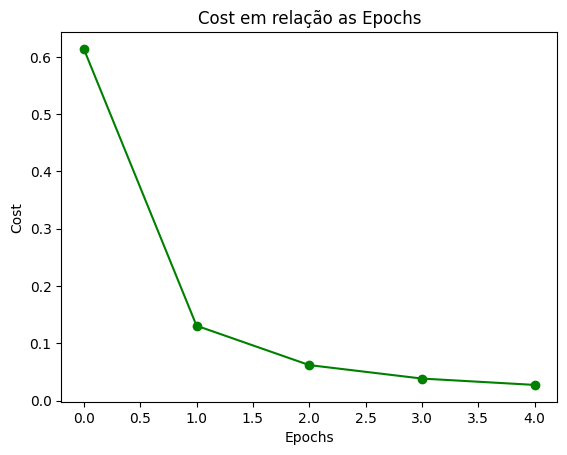

In [74]:
plt.plot(j_history, 'go-',label='Cost')
plt.title('Cost em relação as Epochs')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.show()

In [75]:
#SALVAR O MODELO APÓS O TREINO
a_file = open('finger_trained_kaggle.pkl', 'wb')
pickle.dump(trained_thetas, a_file)
a_file.close()